In [1]:
import scanpy as sc
import phate
import numpy as np
from plotly3d.plot import scatter
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scprep
import graphtools
import magic
import pandas as pd
import dask.dataframe as dd
from dask.distributed import Client

/gpfs/gibbs/project/gerstein/kx44/conda_envs/new_scanpy_env/lib/python3.9/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 12.0.1. Please consider upgrading.
  warnings.warn(


In [2]:
treatment_matrix_path = "/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/treatment_matrix.mtx"
control_matrix_path = "/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/control_matrix.mtx"
treatment_genes_path = "/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/treatment_genes.tsv"
control_genes_path = "/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/control_genes.tsv"
treatment_barcodes_path = "/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/treatment_barcodes.tsv"
control_barcodes_path = "/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/control_barcodes.tsv"

# Load the treatment and control matrices
treatment_adata = sc.read_mtx(treatment_matrix_path).T
control_adata = sc.read_mtx(control_matrix_path).T

# Load the gene names and cell barcodes for treatment and control
treatment_genes = pd.read_csv(treatment_genes_path, header=None, sep="\t")[0].values
control_genes = pd.read_csv(control_genes_path, header=None, sep="\t")[0].values
treatment_barcodes = pd.read_csv(treatment_barcodes_path, header=None, sep="\t")[0].values
control_barcodes = pd.read_csv(control_barcodes_path, header=None, sep="\t")[0].values


In [3]:
treatment_adata.var_names = treatment_genes 
treatment_adata.obs_names = treatment_barcodes

control_adata.var_names = control_genes
control_adata.obs_names = control_barcodes

In [4]:
treatment_adata.shape


(12706, 36601)

In [5]:
control_adata.shape

(201743, 36601)

In [6]:
adata = treatment_adata.concatenate(control_adata, batch_categories=["treatment", "control"])


/tmp/tmp.iDNjprw1K3/ipykernel_2149460/3118706276.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = treatment_adata.concatenate(control_adata, batch_categories=["treatment", "control"])


In [7]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [8]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

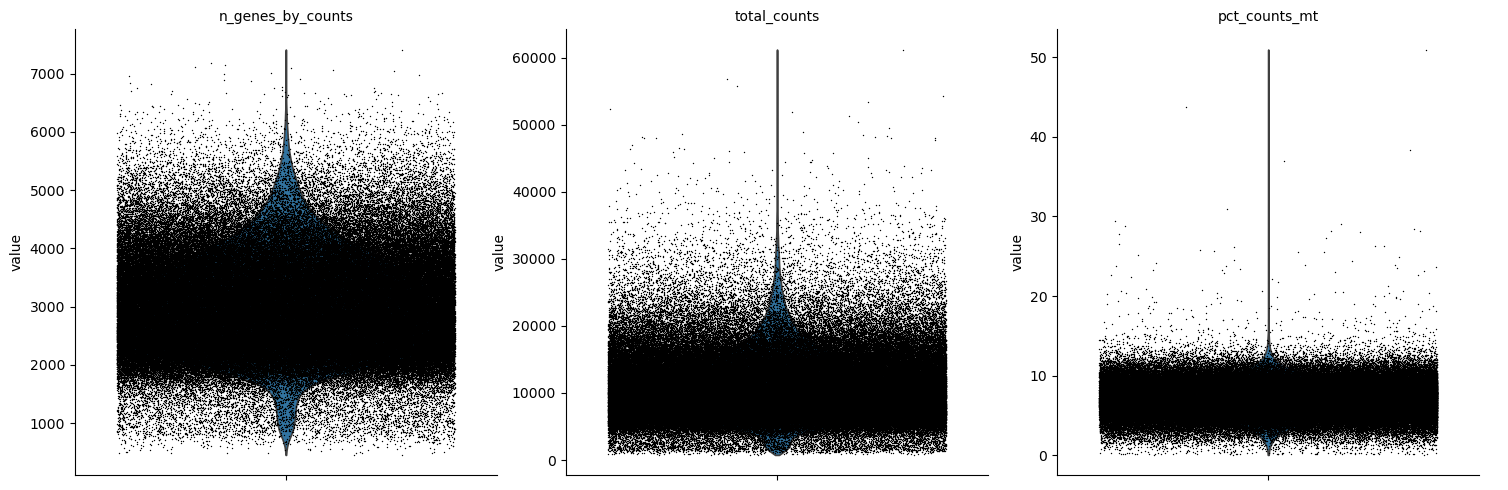

In [9]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

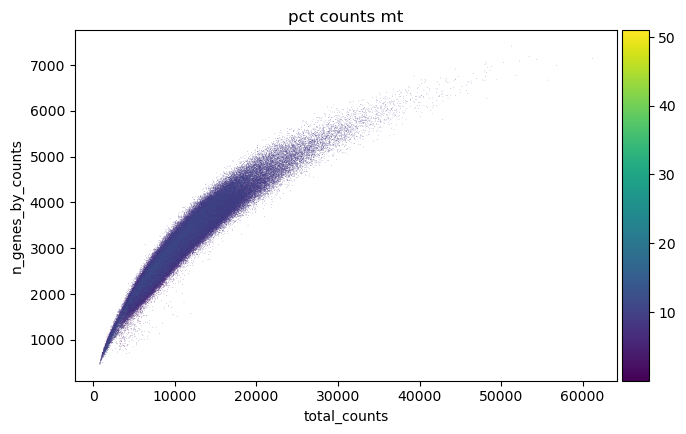

In [10]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [11]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [12]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

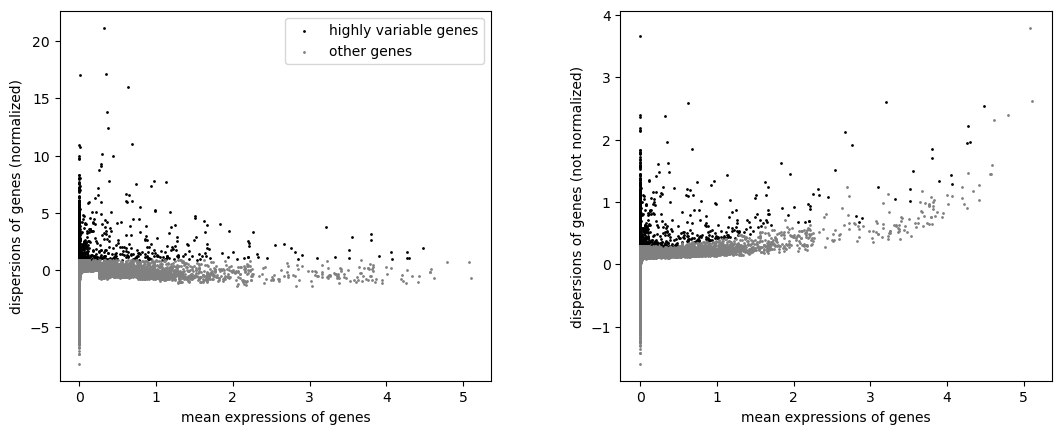

In [15]:
sc.pl.highly_variable_genes(adata)

In [16]:
sc.tl.pca(adata)

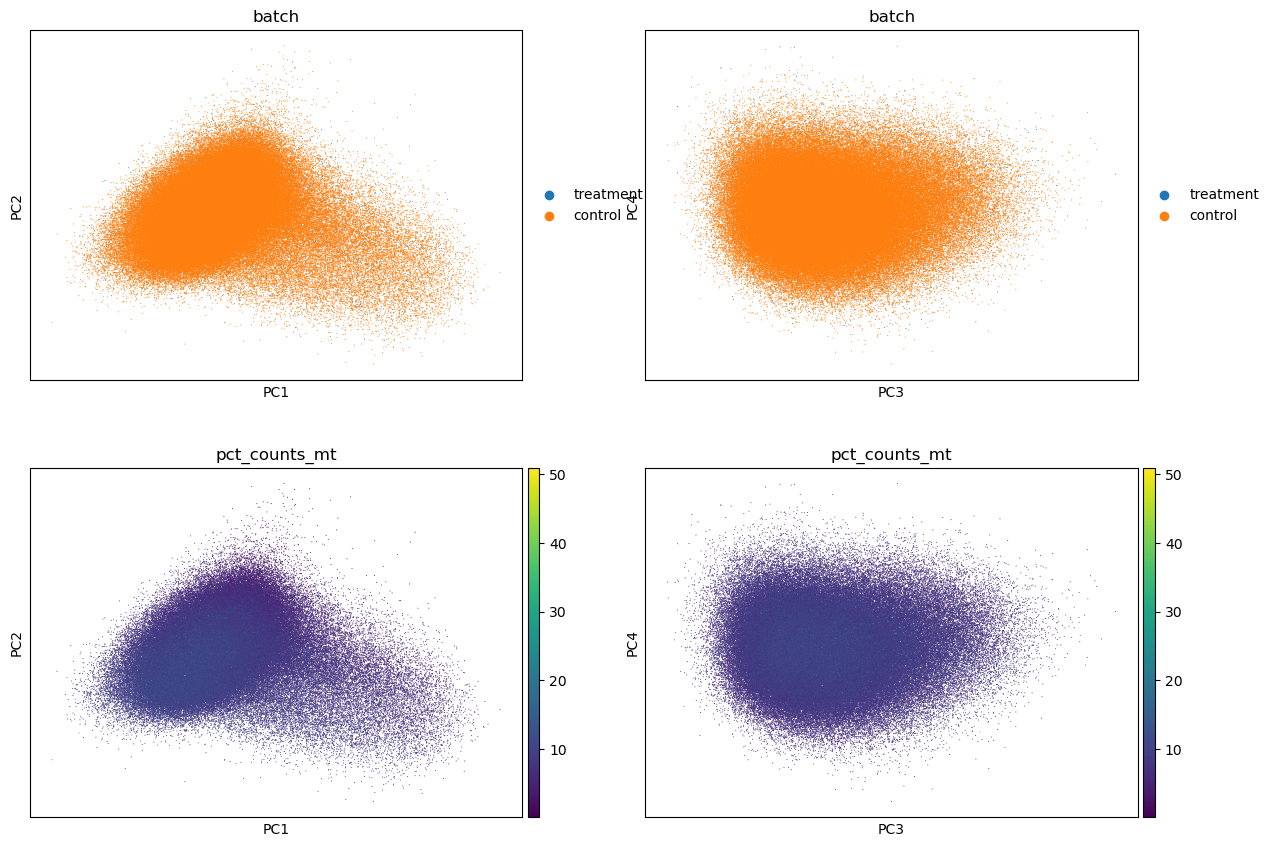

In [17]:
sc.pl.pca(
    adata,
    color=["batch", "batch", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [18]:
sc.pp.neighbors(adata)

/gpfs/gibbs/project/gerstein/kx44/conda_envs/new_scanpy_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
sc.tl.umap(adata)

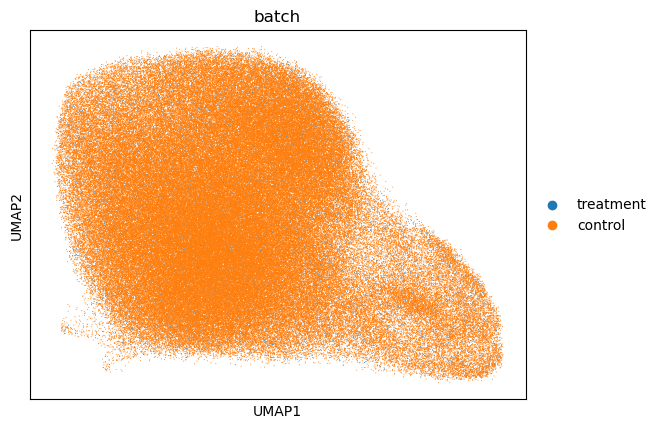

In [20]:
sc.pl.umap(
    adata,
    color="batch",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [ ]:
# extract infor using the index based on this ` PerturbedGene:Guide:CBC-batch-treatment`
bath_fn = lambda x: x.split(":")[-1].split("-")[1]
experiment_fn = lambda x: x.split("-")[-1]
batch = adata.obs.index.map(bath_fn)
experiment = adata.obs.index.map(experiment_fn)
adata.obs["batch"] = batch.values.astype(str)
adata.obs["experiment"] = experiment.values.astype(str)
# remove the group column from the adata.obs
adata.obs.drop(columns=["group"], inplace=True)
# batch is a string, rename the current column to batch_name
# and create a new one with an integer representation
adata.obs['batch_name'] = adata.obs['batch']
adata.obs['batch'] = adata.obs['batch'].astype('category').cat.codes.astype('int')

In [21]:
adata.write_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/preprocessed_perturb_seq.h5ad")

In [5]:
adata = sc.read_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/preprocessed_perturb_seq.h5ad")

In [6]:
flat_index = adata.obs.index.map(lambda x: ':'.join(x) if isinstance(x, tuple) else x)

# Split the flat index into 'Perturbed Gene', 'Perturbation Barcode', and 'Full Cell Info'
split_data = pd.DataFrame(
    [entry.split(':') + ['Unknown'] * (3 - len(entry.split(':'))) for entry in flat_index],
    index=adata.obs.index,
    columns=['perturbed_gene', 'perturbation_barcode	', 'Full Cell Info']
)

# Further split the 'Full Cell Info' column to extract 'Cell Barcode', 'Experiment', and 'Group'
split_data[['cell_barcode', 'experiment', 'group']] = split_data['Full Cell Info'].str.extract(r'([^-]+)-([^-]+)-(.+)')

# Drop the temporary 'Full Cell Info' column as it's no longer needed
split_data.drop(columns=['Full Cell Info'], inplace=True)

# Assign the cleaned split data directly to the new columns in adata.obs
adata.obs[['perturbed_gene', 'perturbation_barcode', 'cell_barcode', 'experiment', 'group']] = split_data

# Display the first few rows to verify the results
adata.obs.head()

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,perturbed_gene,perturbation_barcode,cell_barcode,experiment,group
JAG1:GATGCGCCCTGCCCGGCGTGC:AAACCCACAATCGCAT-scRNAseq_2kG_11AMDox_1-treatment,treatment,4528,8.418256,21486.0,9.975204,33.468305,45.773992,55.668808,67.406683,2345.0,...,8.620652,25.802847,0.0,0.0,0.0,JAG1,GATGCGCCCTGCCCGGCGTGC,AAACCCACAATCGCAT,scRNAseq_2kG_11AMDox_1,treatment
AGAP2:GAAGTGAGGTCGACAGACGGA:AAACCCATCTCCGAAA-scRNAseq_2kG_11AMDox_1-treatment,treatment,3883,8.264621,15760.0,9.665294,31.453046,44.035533,54.517766,66.865482,1431.0,...,8.316789,25.958120,0.0,0.0,0.0,AGAP2,GAAGTGAGGTCGACAGACGGA,AAACCCATCTCCGAAA,scRNAseq_2kG_11AMDox_1,treatment
PCMTD2:GCCGCGGGCCTGGCACTTAAA:AAAGGTAAGGCACAAC-scRNAseq_2kG_11AMDox_1-treatment,treatment,3037,8.018955,11171.0,9.321166,31.304270,44.624474,55.939486,69.232835,919.0,...,8.063377,28.421806,0.0,0.0,0.0,PCMTD2,GCCGCGGGCCTGGCACTTAAA,AAAGGTAAGGCACAAC,scRNAseq_2kG_11AMDox_1,treatment
PLEKHH3:GCCCCGGGACTGGCGCGCTG:AAAGTCCAGGTGATAT-scRNAseq_2kG_11AMDox_1-treatment,treatment,3497,8.159947,13190.0,9.487290,31.152388,45.102350,55.799848,67.680061,694.0,...,8.339501,31.728584,0.0,0.0,0.0,PLEKHH3,GCCCCGGGACTGGCGCGCTG,AAAGTCCAGGTGATAT,scRNAseq_2kG_11AMDox_1,treatment
CHCHD10:GCCACCGCCGCCACCATGCCT:AACAAAGCAGCGCGTT-scRNAseq_2kG_11AMDox_1-treatment,treatment,3789,8.240121,14981.0,9.614605,29.857820,42.360323,52.646686,65.803351,1268.0,...,8.272315,26.119751,0.0,0.0,0.0,CHCHD10,GCCACCGCCGCCACCATGCCT,AACAAAGCAGCGCGTT,scRNAseq_2kG_11AMDox_1,treatment


In [9]:
group_batch_comparison = (adata.obs['group'] == adata.obs['batch'])
group_batch_comparison.value_counts()


True    214449
Name: count, dtype: int64

In [10]:
adata.write_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/preprocessed_perturb_seq.h5ad")

In [2]:
adata = sc.read_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/preprocessed_perturb_seq.h5ad")

In [3]:
adata.X = adata.X.toarray()

In [4]:
type(adata.X)

numpy.ndarray

In [5]:
adata.write_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink-te/datasets/gupta/preprocessed_perturb_seq.h5ad")

: 

In [2]:
adata = sc.read_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink_tmp/preprocessed_perturb_seq.h5ad")

In [3]:
from scipy.sparse import issparse

if issparse(adata.X):
    print("adata.X is sparse.")
else:
    print("adata.X is dense.")

adata.X is sparse.


In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000)
# Subset the adata object to include only the top 200 HVGs
top_5000_hvg = adata.var[adata.var['highly_variable']].head(5000).index
subset_adata = adata[:, top_5000_hvg]

In [8]:
# Save the subsetted adata object to a file
subset_adata = subset_adata.copy()
subset_adata.X = subset_adata.X.toarray()
#subset_adata.write_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink-te/datasets/gupta/subset_top_5000_hvg.h5ad")

In [9]:
type(subset_adata.X)

numpy.ndarray

In [10]:
if issparse(subset_adata.X):
    print("subset_adata.X is sparse.")
else:
    print("subset_adata.X is dense.")

subset_adata.X is dense.


In [11]:
subset_adata.write_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink-te/datasets/gupta/subset_top_5000_hvg.h5ad")

In [6]:
adata = sc.read_h5ad("/gpfs/gibbs/pi/krishnaswamy_smita/kx44/projects/geosink-te/datasets/gupta/subset_top_5000_hvg.h5ad")

In [7]:
from scipy.sparse import issparse

if issparse(adata.X):
    print("adata.X is sparse.")
else:
    print("adata.X is dense.")

adata.X is sparse.


In [5]:
subset_adata

View of AnnData object with n_obs × n_vars = 214449 × 5000
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'perturbed_gene', 'perturbation_barcode', 'cell_barcode', 'experiment', 'group'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'